In [ ]:
%pip install torch numpy pretty_midi matplotlib scikit-learn gdown

In [13]:
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS).")
else:
    device = torch.device("cpu")
    print("Using CPU.")


Using Apple Silicon GPU (MPS).


## 1. Load Processed Data
Load X, y, vocabulary, and train/validation/test indices created during preprocessing.

In [14]:
from pathlib import Path

data_path = Path("data/processed/full_sequences.npz")
data = np.load(data_path, allow_pickle=True)

X_ids = data["X"]
y_ids = data["y"]
vocab = data["vocab"]
SEQ_LEN = X_ids.shape[1]

print("Loaded dataset from:", data_path)
print("  X_ids shape:", X_ids.shape)
print("  y_ids shape:", y_ids.shape)
print("  vocab size:", vocab.shape[0])
print("  SEQ_LEN:", SEQ_LEN)


Loaded dataset from: data/processed/full_sequences.npz
  X_ids shape: (683118, 50)
  y_ids shape: (683118,)
  vocab size: 307
  SEQ_LEN: 50


In [6]:
from pathlib import Path

splits_path = Path("data/processed/splits_filelevel_indices.npz")
splits = np.load(splits_path)

train_idx = splits["train_idx"]
val_idx   = splits["val_idx"]
test_idx  = splits["test_idx"]

print("Loaded splits from:", splits_path)
print("  Train examples:", len(train_idx))
print("  Val examples:  ", len(val_idx))
print("  Test examples: ", len(test_idx))

Loaded splits from: data/processed/splits_filelevel_indices.npz
  Train examples: 487526
  Val examples:   92563
  Test examples:  103029


## 2. Dataset and DataLoaders
Wrap the sequences into a PyTorch Dataset and build DataLoaders with batching and shuffling.


In [16]:
from torch.utils.data import Dataset, DataLoader

print("Using device:", device)

class MusicSequenceDataset(Dataset):
    """
    Wraps X_ids and y_ids, but only exposes the rows given by index_array.
    Each __getitem__ returns (input_seq, target_token) as torch tensors.
    """
    def __init__(self, X_all, y_all, index_array):
        self.X_all = X_all
        self.y_all = y_all
        self.index_array = index_array  # e.g., train_idx, val_idx, test_idx

    def __len__(self):
        return len(self.index_array)

    def __getitem__(self, idx):
        real_idx = self.index_array[idx]
        x = self.X_all[real_idx]   # shape: (SEQ_LEN,)
        y = self.y_all[real_idx]   # scalar

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

BATCH_SIZE = 128

train_dataset = MusicSequenceDataset(X_ids, y_ids, train_idx)
val_dataset   = MusicSequenceDataset(X_ids, y_ids, val_idx)
test_dataset  = MusicSequenceDataset(X_ids, y_ids, test_idx)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:  ", len(val_dataset))
print("Test dataset size: ", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

batch_x, batch_y = next(iter(train_loader))
print("One batch X shape:", batch_x.shape)
print("One batch y shape:", batch_y.shape)
print("X dtype:", batch_x.dtype, "| y dtype:", batch_y.dtype)

Using device: mps
Train dataset size: 487526
Val dataset size:   92563
Test dataset size:  103029
One batch X shape: torch.Size([128, 50])
One batch y shape: torch.Size([128])
X dtype: torch.int64 | y dtype: torch.int64


## 3. Define GRU Model (Custom Architecture)
Define the embedding, GRU, dropout, and linear layers used to predict the next token.

In [ ]:
import torch.nn as nn

VOCAB_SIZE = vocab.shape[0]
SEQ_LEN = X_ids.shape[1]
print("VOCAB_SIZE:", VOCAB_SIZE, "| SEQ_LEN:", SEQ_LEN)

class MusicGRUModel(nn.Module):
    """
    Embedding -> GRU -> Linear
    Input:  (batch_size, seq_len) of token IDs
    Output: (batch_size, vocab_size) logits for the next token
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=1, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        gru_dropout = dropout if num_layers > 1 else 0.0
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=gru_dropout,
        )

        self.dropout_layer = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """
        x: (batch_size, seq_len) of token IDs
        """
        emb = self.embedding(x)             
        out, h_n = self.gru(emb)           
        last_hidden = out[:, -1, :]   
        last_hidden = self.dropout_layer(last_hidden)     
        logits = self.fc(last_hidden)      
        return logits

model = MusicGRUModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
).to(device)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Number of trainable parameters:", num_params)

VOCAB_SIZE: 307 | SEQ_LEN: 50
MusicGRUModel(
  (embedding): Embedding(307, 64)
  (gru): GRU(64, 128, batch_first=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=307, bias=True)
)
Number of trainable parameters: 133747


## 4. Training Loop (GPU-Accelerated)
Train the GRU model using MPS/Apple Silicon GPU acceleration and measure accuracy/loss.

In [ ]:
import time

NUM_EPOCHS = 10
PRINT_EVERY = 1

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_state_dict = None  # will store weights of best model
patience = 2         # stop after 2 epochs with no improvement
patience_counter = 0


def run_epoch(loader, model, criterion, optimizer=None):
    """
    Run one epoch.
    If optimizer is provided -> training mode (backprop).
    If optimizer is None      -> evaluation mode (no grad).
    Returns (avg_loss, accuracy).
    """
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        correct = (preds == batch_y).sum().item()
        total_correct += correct
        total_examples += batch_x.size(0)

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = run_epoch(
        train_loader, model, criterion, optimizer=optimizer
    )

    with torch.no_grad():
        val_loss, val_acc = run_epoch(
            val_loader, model, criterion, optimizer=None
        )
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        print(f"  New best model at epoch {epoch} (val_loss={val_loss:.4f})")
    
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}. No improvement in {patience} epochs.")
            break

    elapsed = time.time() - start_time

    if epoch % PRINT_EVERY == 0:
        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} "
            f"- {elapsed:.1f}s | "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
        )

print("Training complete.")
print("Best validation loss:", best_val_loss)

  New best model at epoch 1 (val_loss=3.1634)
Epoch 01/10 - 71.7s | train_loss: 3.3579, train_acc: 0.1745 | val_loss: 3.1634, val_acc: 0.2081
  New best model at epoch 2 (val_loss=3.0584)
Epoch 02/10 - 73.2s | train_loss: 3.0751, train_acc: 0.2211 | val_loss: 3.0584, val_acc: 0.2258
  New best model at epoch 3 (val_loss=3.0084)
Epoch 03/10 - 74.5s | train_loss: 2.9973, train_acc: 0.2369 | val_loss: 3.0084, val_acc: 0.2392
  New best model at epoch 4 (val_loss=2.9648)
Epoch 04/10 - 74.2s | train_loss: 2.9482, train_acc: 0.2475 | val_loss: 2.9648, val_acc: 0.2443
  New best model at epoch 5 (val_loss=2.9443)
Epoch 05/10 - 76.8s | train_loss: 2.9136, train_acc: 0.2550 | val_loss: 2.9443, val_acc: 0.2486
  New best model at epoch 6 (val_loss=2.9192)
Epoch 06/10 - 75.7s | train_loss: 2.8867, train_acc: 0.2615 | val_loss: 2.9192, val_acc: 0.2537
  New best model at epoch 7 (val_loss=2.9058)
Epoch 07/10 - 76.0s | train_loss: 2.8643, train_acc: 0.2674 | val_loss: 2.9058, val_acc: 0.2586
  New 

## 5. Training Curves (Loss & Accuracy)
Visualize training and validation performance over time to diagnose overfitting.


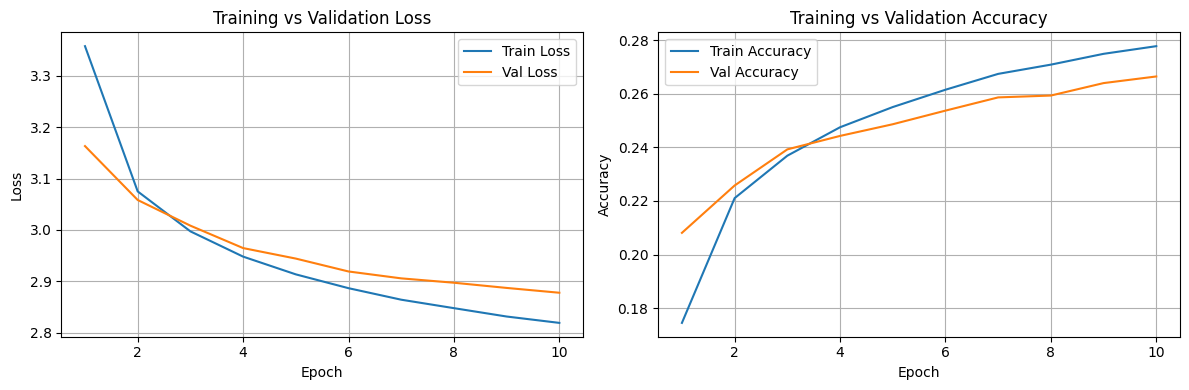

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 6. Model Evaluation on Test Set
Evaluate the trained GRU model on the held-out test set.


In [20]:
# Use the best validation model if we have it
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("Loaded best model (by validation loss) for test evaluation.")

model.eval()
with torch.no_grad():
    test_loss, test_acc = run_epoch(
        test_loader, model, criterion, optimizer=None
    )

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"\nMajority baseline test accuracy: {baseline_test_acc:.4f}")

Loaded best model (by validation loss) for test evaluation.
Test loss: 2.8211
Test accuracy: 0.2812

Majority baseline test accuracy: 0.0411


## 7. Save Final Model Checkpoint
Save trained model weights and metadata to the models/ directory.


In [22]:
import os

os.makedirs("models", exist_ok=True)

MODEL_PATH = "models/music_gru_checkpoint.pt"

checkpoint = {
    "state_dict": best_state_dict if best_state_dict is not None else model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "seq_len": SEQ_LEN,
    "embed_dim": 64,
    "hidden_dim": 128,
    "num_layers": 1,
    "dropout": 0.3,
}

torch.save(checkpoint, MODEL_PATH)
print(f"Saved model checkpoint to {MODEL_PATH}")


Saved model checkpoint to models/music_gru_checkpoint.pt


## 8. Hyperparameter Tuning Function
A helper function for training and evaluating GRU models with different hyperparameters to support model comparison experiments.

In [23]:
def train_config(
    name,
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-5,
    num_epochs=6,
):
    """
    Train a new MusicGRUModel with the given hyperparameters.
    Uses the same train/val loaders and run_epoch function.
    Returns: (history_dict, best_val_acc)
    """
    print(f"\n=== Training config: {name} ===")
    print(f"embed_dim={embed_dim}, hidden_dim={hidden_dim}, "
          f"num_layers={num_layers}, dropout={dropout}, lr={lr}, "
          f"weight_decay={weight_decay}, epochs={num_epochs}")

    # Fresh model & optimizer for this config
    config_model = MusicGRUModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    config_criterion = nn.CrossEntropyLoss()
    config_optimizer = torch.optim.Adam(
        config_model.parameters(), lr=lr, weight_decay=weight_decay
    )

    cfg_train_losses = []
    cfg_val_losses = []
    cfg_train_accuracies = []
    cfg_val_accuracies = []

    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        train_loss, train_acc = run_epoch(
            train_loader, config_model, config_criterion, optimizer=config_optimizer
        )

        with torch.no_grad():
            val_loss, val_acc = run_epoch(
                val_loader, config_model, config_criterion, optimizer=None
            )

        cfg_train_losses.append(train_loss)
        cfg_val_losses.append(val_loss)
        cfg_train_accuracies.append(train_acc)
        cfg_val_accuracies.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:02d}/{num_epochs} - {elapsed:.1f}s | "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}"
        )

    history = {
        "train_losses": cfg_train_losses,
        "val_losses": cfg_val_losses,
        "train_accuracies": cfg_train_accuracies,
        "val_accuracies": cfg_val_accuracies,
    }

    print(f"Best val accuracy for {name}: {best_val_acc:.4f}")
    return history, best_val_acc


## 9. Hyperparameter Tuning Experiments
Compare performance across multiple model sizes or configurations.


In [24]:
# Hyperparameter experiments: small vs bigger GRU

history_small, best_val_acc_small = train_config(
    name="small_GRU",
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    num_epochs=6,
)

history_big, best_val_acc_big = train_config(
    name="bigger_GRU",
    embed_dim=128,
    hidden_dim=256,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    num_epochs=6,
)

print("\nSummary of hyperparameter configs:")
print(f"  small_GRU  best val acc: {best_val_acc_small:.4f}")
print(f"  bigger_GRU best val acc: {best_val_acc_big:.4f}")
print(f"\nMajority baseline val accuracy: {baseline_val_acc:.4f}")



=== Training config: small_GRU ===
embed_dim=64, hidden_dim=128, num_layers=1, dropout=0.3, lr=0.001, weight_decay=1e-05, epochs=6
Epoch 01/6 - 73.0s | train_loss: 3.3367, train_acc: 0.1793 | val_loss: 3.1404, val_acc: 0.2121
Epoch 02/6 - 77.0s | train_loss: 3.0531, train_acc: 0.2261 | val_loss: 3.0508, val_acc: 0.2310
Epoch 03/6 - 76.1s | train_loss: 2.9757, train_acc: 0.2432 | val_loss: 3.0073, val_acc: 0.2391
Epoch 04/6 - 75.1s | train_loss: 2.9240, train_acc: 0.2540 | val_loss: 2.9754, val_acc: 0.2461
Epoch 05/6 - 75.7s | train_loss: 2.8903, train_acc: 0.2618 | val_loss: 2.9624, val_acc: 0.2466
Epoch 06/6 - 76.9s | train_loss: 2.8603, train_acc: 0.2685 | val_loss: 2.9509, val_acc: 0.2499
Best val accuracy for small_GRU: 0.2499

=== Training config: bigger_GRU ===
embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.3, lr=0.001, weight_decay=1e-05, epochs=6
Epoch 01/6 - 79.5s | train_loss: 3.1669, train_acc: 0.2117 | val_loss: 3.0373, val_acc: 0.2322
Epoch 02/6 - 79.3s | train_lo